Dataset Size = 20
Number of updates before convergence: 2


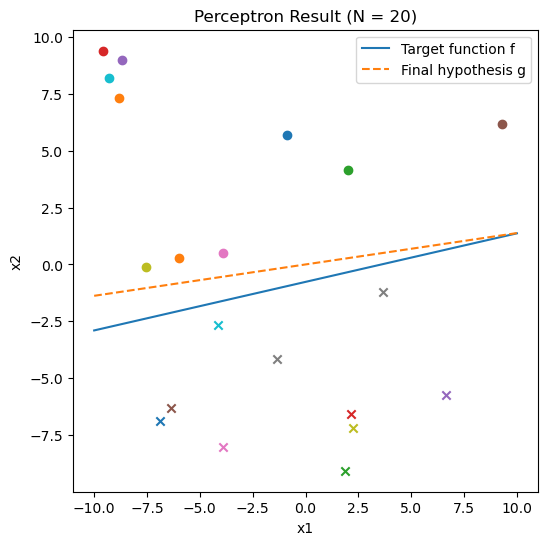


Dataset Size = 100
Number of updates before convergence: 41


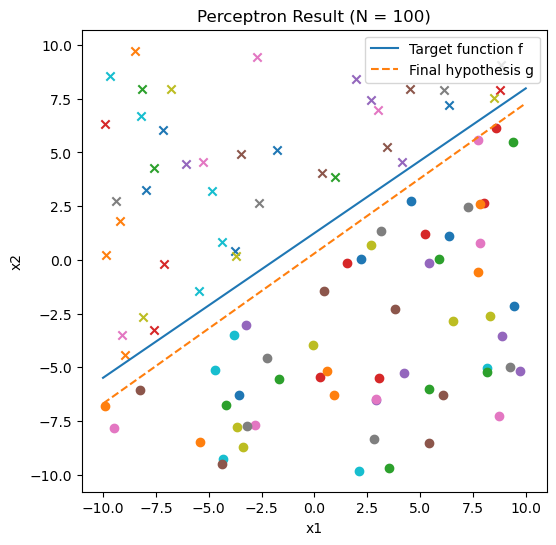

In [11]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)


def generate_data(N):

    w_true = np.random.randn(3,1)

    # Generate random points
    X = np.random.uniform(-10, 10, (N,2))
    X_bias = np.hstack((np.ones((N,1)), X))

    # Assign labels using target function
    y = np.sign(X_bias @ w_true)
    y[y==0] = 1

    return X, X_bias, y, w_true


def perceptron(X_bias, y):
    N, d = X_bias.shape
    w = np.zeros((d,1))
    updates = 0

    while True:
        error_count = 0
        for i in range(N):
            if y[i] * (X_bias[i].reshape(1,-1) @ w) <= 0:
                w += y[i] * X_bias[i].reshape(-1,1)
                updates += 1
                error_count += 1
        if error_count == 0:
            break

    return w, updates


def plot_results(X, y, w_true, w_final, title):
    plt.figure(figsize=(6,6))

    # Plot data points
    for i in range(len(y)):
        if y[i] == 1:
            plt.scatter(X[i,0], X[i,1], marker='o')
        else:
            plt.scatter(X[i,0], X[i,1], marker='x')

    x_vals = np.linspace(-10,10,100)
    y_true_line = -(w_true[0] + w_true[1]*x_vals)/w_true[2]
    plt.plot(x_vals, y_true_line, label="Target function f")

    y_final_line = -(w_final[0] + w_final[1]*x_vals)/w_final[2]
    plt.plot(x_vals, y_final_line, linestyle='--', label="Final hypothesis g")

    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.legend()
    plt.show()


N1 = 20
X1, X1_bias, y1, w_true1 = generate_data(N1)
w_final1, updates1 = perceptron(X1_bias, y1)

print("Dataset Size = 20")
print("Number of updates before convergence:", updates1)

plot_results(X1, y1, w_true1, w_final1,
             "Perceptron Result (N = 20)")


N2 = 100
X2, X2_bias, y2, w_true2 = generate_data(N2)
w_final2, updates2 = perceptron(X2_bias, y2)

print("\nDataset Size = 100")
print("Number of updates before convergence:", updates2)

plot_results(X2, y2, w_true2, w_final2,
             "Perceptron Result (N = 100)")


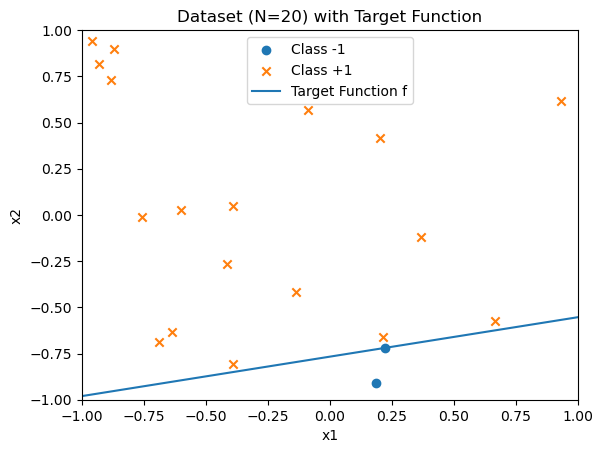

Number of updates for N=20: 70


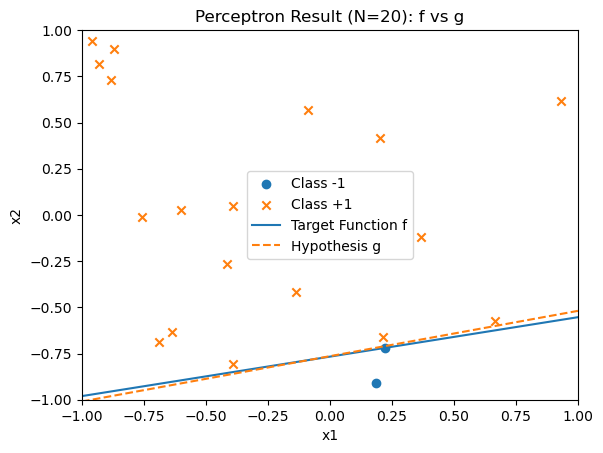

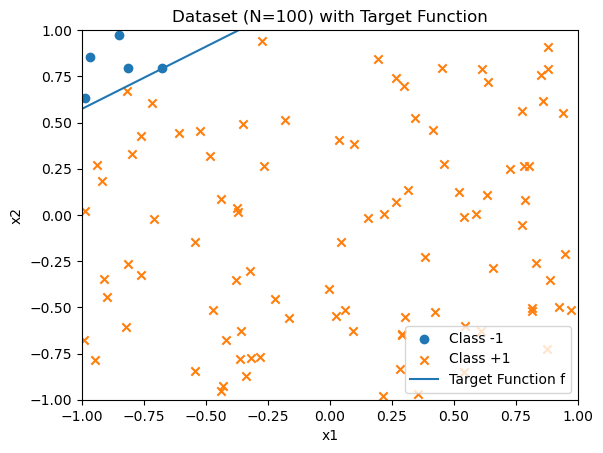

Number of updates for N=100: 44


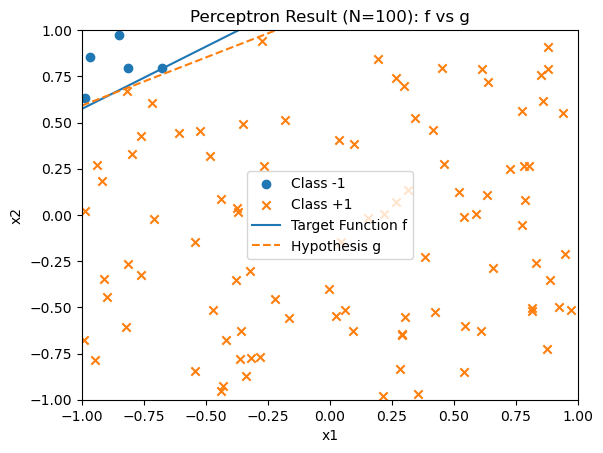

In [10]:
# Generate dataset
X100, y100, w_target100 = generate_linearly_separable_data(100)

# Plot dataset and target function
plot_data(X100, y100, w_target=w_target100,
          title="Dataset (N=100) with Target Function")

# Run perceptron
w_final100, updates100 = perceptron(X100, y100)

print("Number of updates for N=100:", updates100)

# Plot final hypothesis
plot_data(X100, y100, w_target=w_target100, w_final=w_final100,
          title="Perceptron Result (N=100): f vs g")
